# Chladni cymatics — chord-driven nodal patterns

The Chladni sand-on-square-plate experiment is the canonical *visual*
representation of musical chord ratios. Sand grains settle on the
**nodal lines** of a vibrating plate — the curves where the plate's
displacement is zero. Different chord ratios excite different
combinations of plate eigenmodes and the resulting nodal lattice
becomes a unique "fingerprint" for each chord.

`RigidPlate` (the eigenmode-family medium in
:mod:`biotuner.harmonic_geometry.media`) exposes two parallel paths:

- **classical (default)** — ``mode_scheme='per_ratio'``: each ratio maps
  to one ``(m, n)`` mode pair via Stern-Brocot, and the field is a sum
  of symmetric ``cos·cos`` products. Works on rectangular, circular,
  polygonal, and 3-D-box plates.
- **cymatics (new)** — ``mode_scheme='pairwise_antisymmetric'``: each
  pair of ratios contributes one *antisymmetric* mode
  ``cos(m)cos(n) - cos(n)cos(m)`` on a square plate. This is the
  iconic Chladni form. Rectangular only.

This notebook walks through the cymatics path: integer-ratio
extraction, the four mode-scheme options, D4 symmetrisation, the
nodal-density transform, two rendering styles (white-sand particles
and a perceptual-cmap "painted" view), the `max_mode` cap that tames
chords with high LCMs, and finally an animation that morphs through a
sequence of chords.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting
from biotuner.harmonic_geometry.media import (
    Granular, Pipeline, RigidPlate,
)
from biotuner.harmonic_geometry.media.eigenmode.rigid_plate import (
    chord_to_int_modes,
    chladni_field_pairwise,
    chladni_field_triple_antisymmetric,
    chladni_nodal_density,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# Small-integer just-intoned chord representations — the natural form
# for the cymatics schemes (one chord ratio = one plate wavenumber).
CHORDS_INT = {
    "Major":  [4, 5, 6],
    "Sus4":   [6, 8, 9],
    "Dom7":   [4, 5, 6, 7],
    "Dim7":   [5, 6, 7, 9],
}


## 1. Lossless integer-ratio extraction

`chord_to_int_modes` multiplies a chord's ``Fraction`` ratios through
by the LCM of their denominators. No rounding. Just-intoned chords
already in small-integer form round-trip unchanged; 12-TET-flavoured
forms can produce surprisingly large integers.


In [2]:
chords_frac = {
    "Major":  [Fraction(1), Fraction(5, 4), Fraction(3, 2)],
    "Dom7":   [Fraction(1), Fraction(5, 4), Fraction(3, 2), Fraction(7, 4)],
    "Dim7-just":  [Fraction(1), Fraction(6, 5), Fraction(7, 5), Fraction(9, 5)],
    "Dim7-12TET": [Fraction(1), Fraction(6, 5), Fraction(7, 5), Fraction(12, 7)],
}
for name, c in chords_frac.items():
    print(f"  {name:12s}  {[str(r) for r in c]}  →  {chord_to_int_modes(c)}")


## 2. The four mode schemes

`RigidPlate` exposes four chord→mode schemes. The classical
``per_ratio`` lives next to three cymatics-style schemes that sum
modes over **pairs** or **triples** of ratios — emphasising the
harmonic *relationships* in the chord rather than the individual
partials.


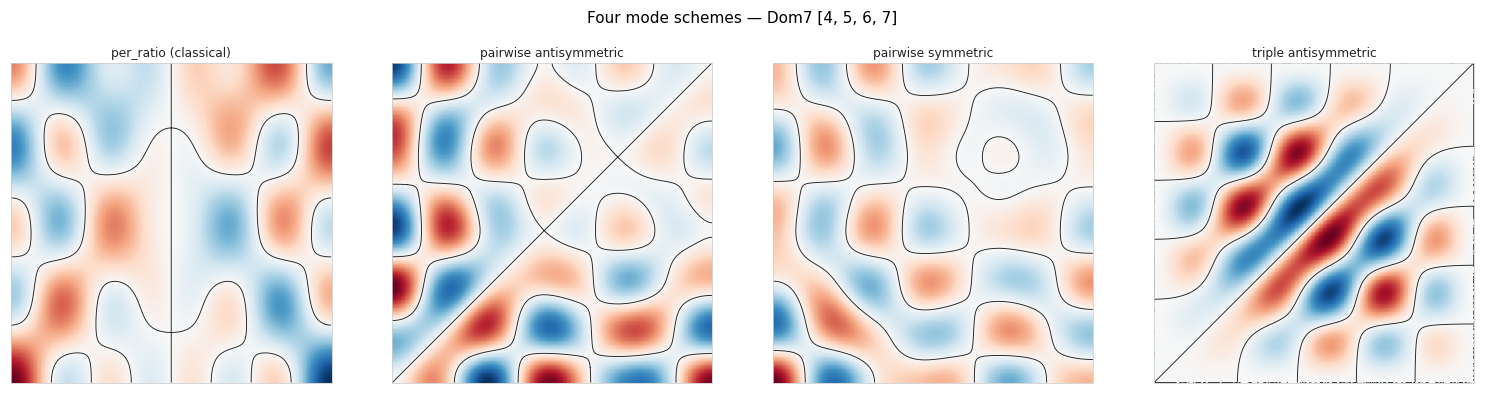

In [3]:
dom7_int = CHORDS_INT["Dom7"]
dom7_hi  = HarmonicInput(ratios=[Fraction(r, 4) for r in dom7_int])

g_pr = RigidPlate(mode_scheme="per_ratio", resolution=400)(dom7_hi)
g_pa = chladni_field_pairwise(dom7_int, antisymmetric=True,  resolution=400)
g_ps = chladni_field_pairwise(dom7_int, antisymmetric=False, resolution=400)
g_tr = chladni_field_triple_antisymmetric(dom7_int, resolution=400)

plotting.gallery(
    [g_pr, g_pa, g_ps, g_tr], n_cols=4,
    titles=["per_ratio (classical)",
            "pairwise antisymmetric",
            "pairwise symmetric",
            "triple antisymmetric"],
    suptitle="Four mode schemes — Dom7 [4, 5, 6, 7]",
    fig_width=14.0,
);


## 3. D4 symmetrisation — applied at the density stage

The classical Chladni demos apply D4 (4-fold rotational + reflective)
symmetrisation to the *density* ``exp(-w²/σ²)``, taking the
element-wise max over the 8-element orbit. This *unions* the nodal
sets across rotations — producing the rich crystalline lattice the
cymatics aesthetic is known for. ``RigidPlate(symmetry='d4_max')``
records the request; ``chladni_nodal_density`` (and the
``Granular(nodal_emphasis=True)`` path) then applies it at the
density stage.


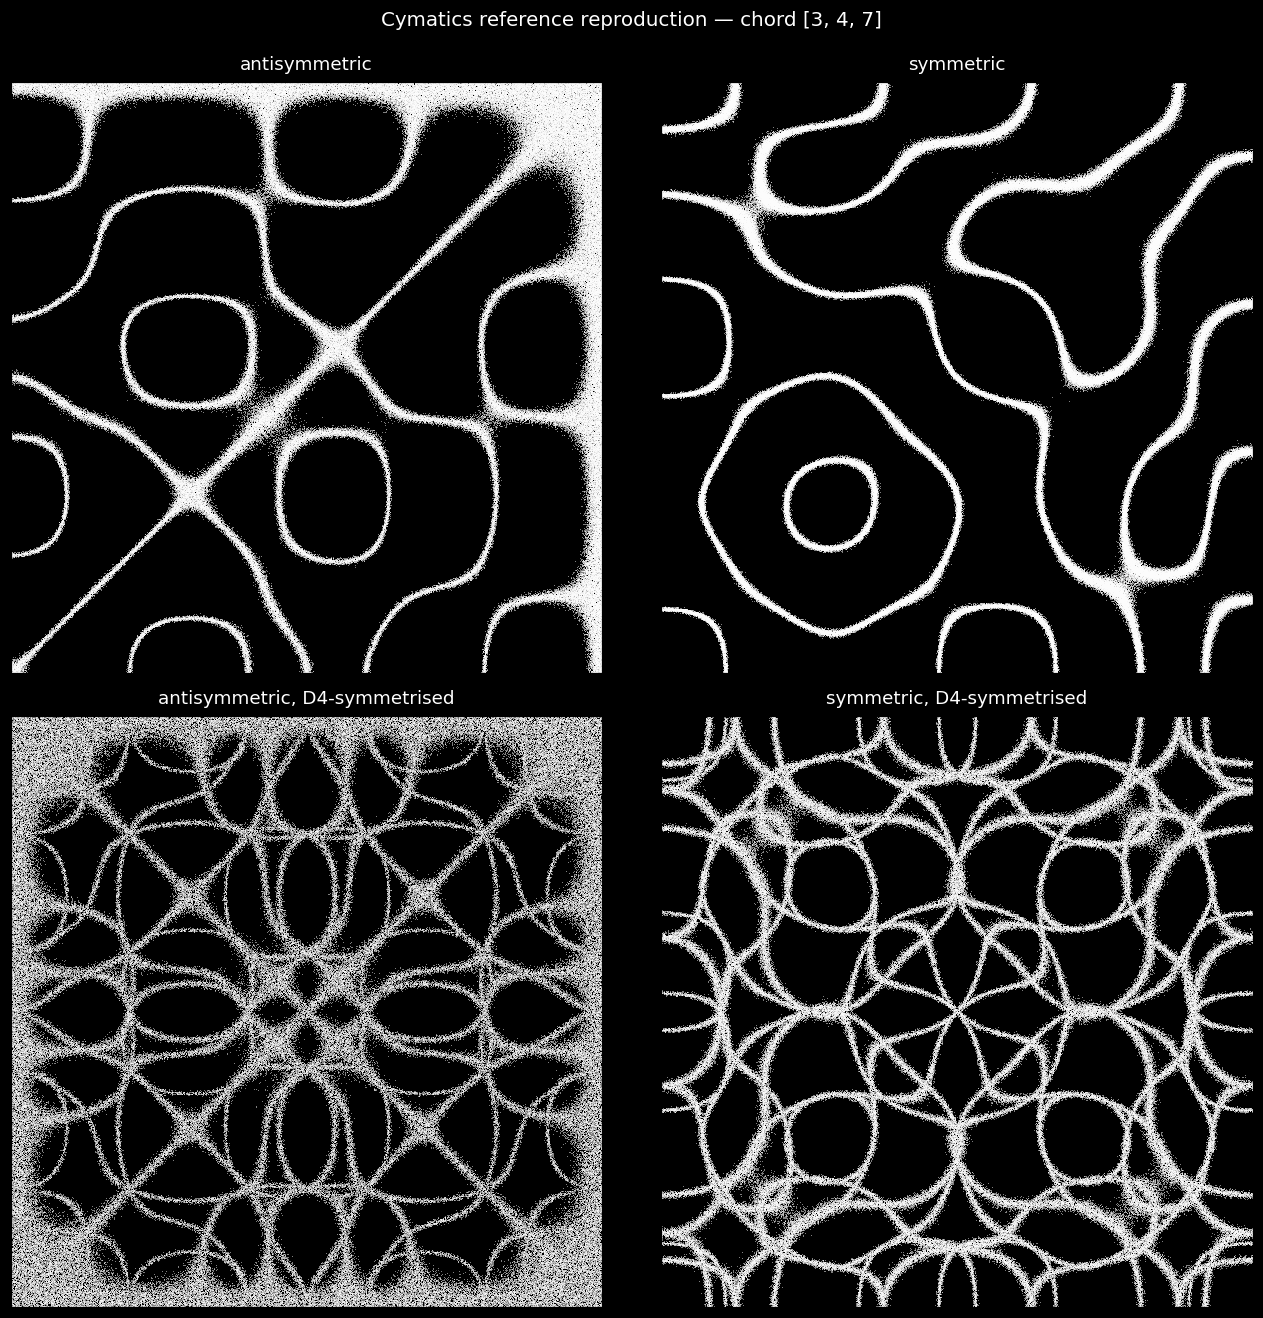

In [4]:
chord = [3, 4, 7]  # the user's original cymatics-demo chord

fig, axes = plt.subplots(2, 2, figsize=(12, 12), facecolor="black")
configs = [
    ("antisymmetric",                  True,  "none"),
    ("symmetric",                      False, "none"),
    ("antisymmetric, D4-symmetrised",  True,  "d4_max"),
    ("symmetric, D4-symmetrised",      False, "d4_max"),
]
for ax, (label, asy, sym) in zip(axes.flat, configs):
    field = chladni_field_pairwise(
        chord, antisymmetric=asy, symmetry=sym,
        resolution=400, pair_subset="all",
    )
    plotting.draw_chladni_sand(field, ax, n_particles=300_000,
                                point_size=0.4, point_alpha=0.4,
                                sigma=0.05)
    ax.set_title(label, color="white", fontsize=12, pad=8)
fig.suptitle(f"Cymatics reference reproduction — chord {chord}",
             color="white", fontsize=13, y=0.995)
fig.tight_layout();


## 4. `pair_subset` — keeping curves bold at any chord size

Summing all ``C(n, 2)`` pair-modes produces continuous curves for
3-ratio chords (the simultaneous zero-set is a curve) but degenerates
into a *set of isolated points* for 4+ ratio chords (the
simultaneous zero-set becomes restrictive). The ``pair_subset``
parameter exposes the workaround: keep only ``n-1`` pairs and the
field stays curve-like at any chord size.

- ``pair_subset='auto'`` (default): ``'all'`` for ``n ≤ 3``,
  ``'root'`` for ``n ≥ 4``.
- ``'all'``: literal mathematical sum (dotty for ``n ≥ 4``).
- ``'adjacent'``: consecutive pairs.
- ``'root'``: pairs that include the first ratio.
- list of ``(m, n)`` tuples: full manual control.


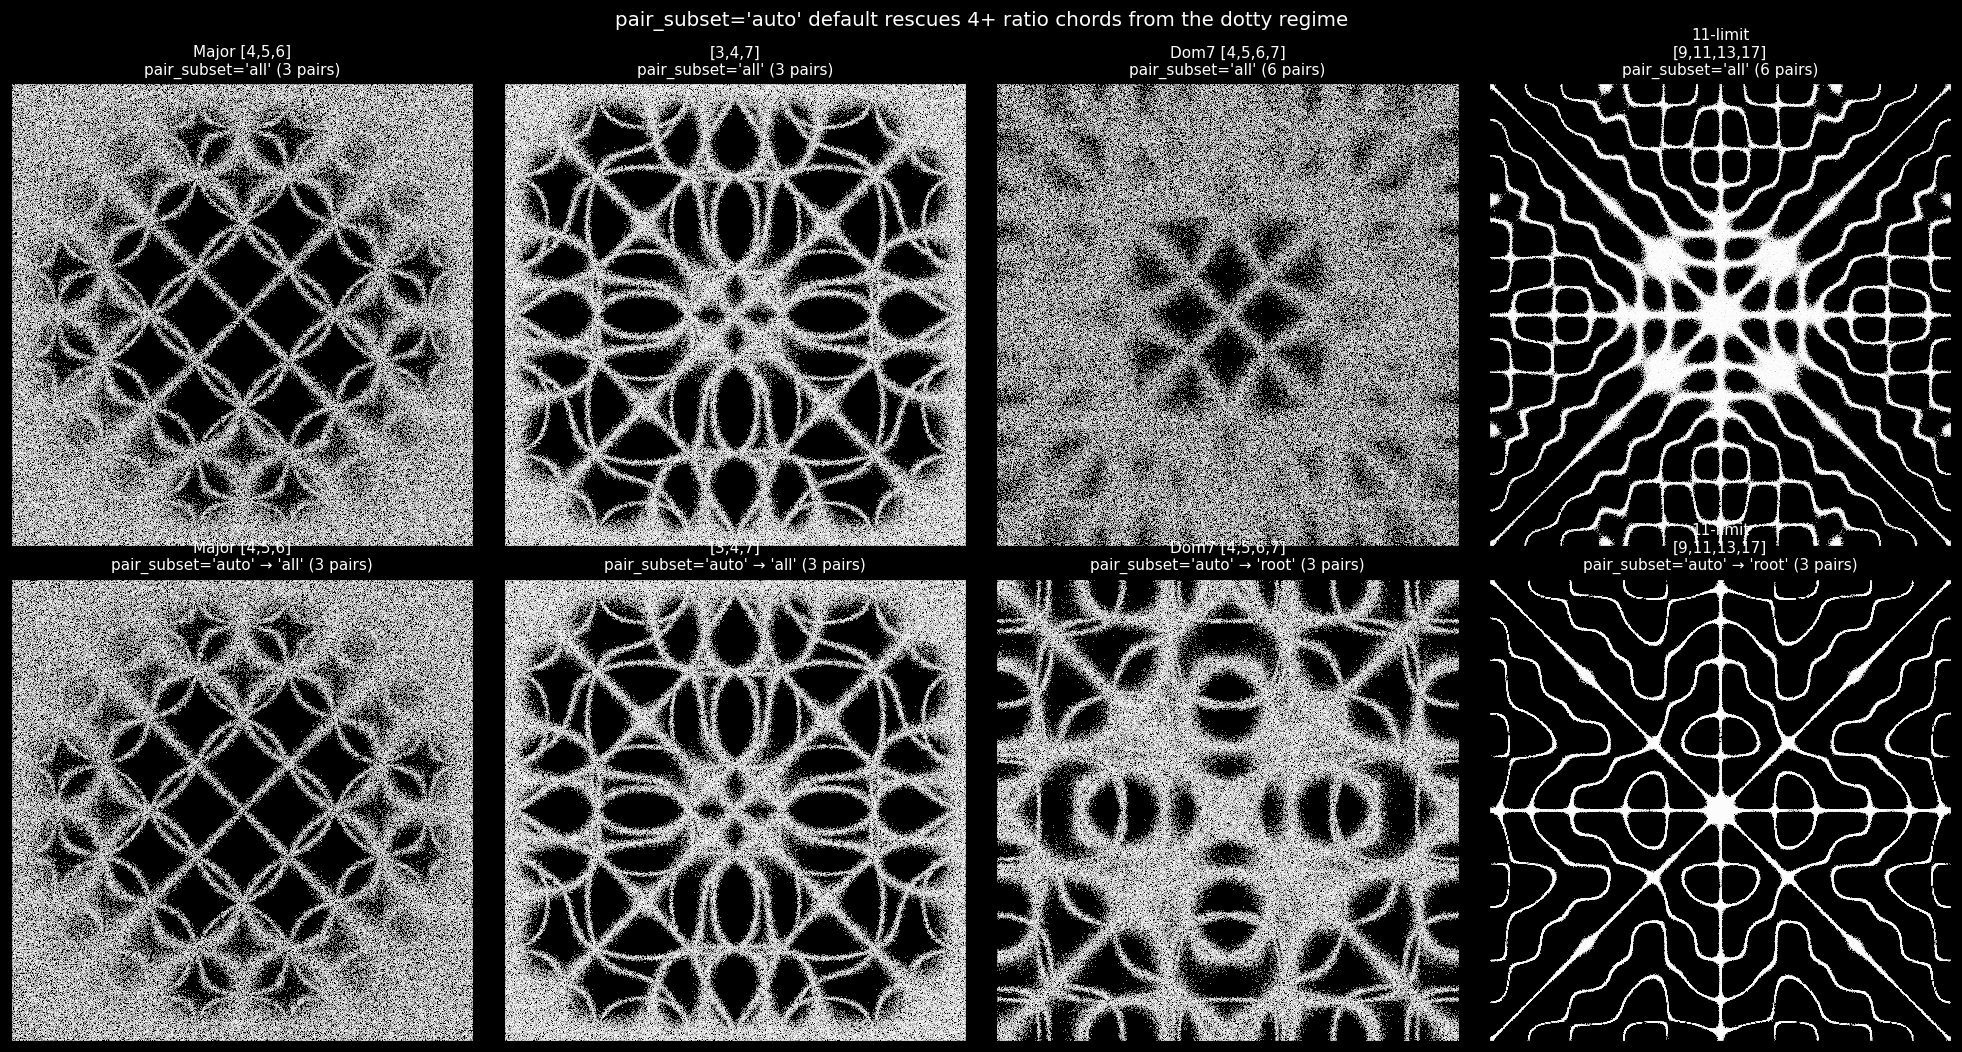

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9.5), facecolor="black")
chords = [
    ("Major [4,5,6]",        [4, 5, 6]),
    ("[3,4,7]",              [3, 4, 7]),
    ("Dom7 [4,5,6,7]",       [4, 5, 6, 7]),
    ("11-limit\n[9,11,13,17]", [9, 11, 13, 17]),
]
for ax, (name, chord) in zip(axes[0], chords):
    f = chladni_field_pairwise(
        chord, antisymmetric=True, symmetry="d4_max",
        resolution=400, pair_subset="all",
    )
    plotting.draw_chladni_sand(f, ax, n_particles=300_000,
                                point_size=0.4, point_alpha=0.4)
    n = f.parameters["n_pairs"]
    ax.set_title(f"{name}\npair_subset='all' ({n} pairs)",
                  color="white", fontsize=10)
for ax, (name, chord) in zip(axes[1], chords):
    f = chladni_field_pairwise(
        chord, antisymmetric=True, symmetry="d4_max",
        resolution=400,  # pair_subset='auto'
    )
    plotting.draw_chladni_sand(f, ax, n_particles=300_000,
                                point_size=0.4, point_alpha=0.4)
    actual = f.parameters["pair_subset"]
    n = f.parameters["n_pairs"]
    ax.set_title(f"{name}\npair_subset='auto' → '{actual}' ({n} pairs)",
                  color="white", fontsize=10)
fig.suptitle("pair_subset='auto' default rescues 4+ ratio chords from the dotty regime",
             color="white", fontsize=13, y=0.995)
fig.tight_layout(pad=0.6);


## 5. Chord-fingerprint gallery — sand-grain rendering

`plotting.draw_chladni_sand` density-samples ``n_particles`` points
from the nodal density and renders them as a black-plate / white-grain
scatter — the photographic Chladni look. Auto-σ from the chord
metadata.


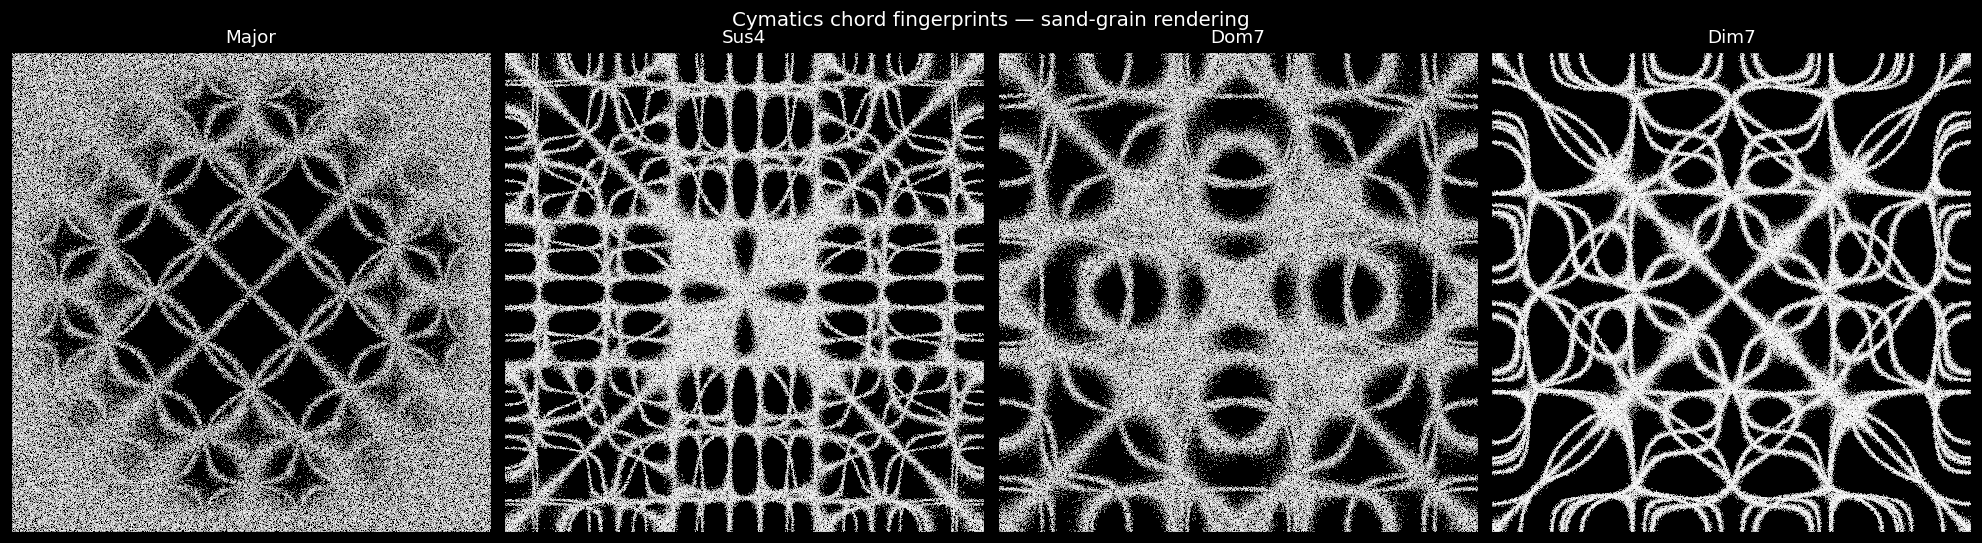

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.7), facecolor="black")
for ax, (name, chord) in zip(axes, CHORDS_INT.items()):
    field = chladni_field_pairwise(
        chord, antisymmetric=True, symmetry="d4_max",
        resolution=400,
    )
    plotting.draw_chladni_sand(field, ax, n_particles=300_000,
                                point_size=0.4, point_alpha=0.4)
    ax.set_title(name, color="white", fontsize=12)
fig.suptitle("Cymatics chord fingerprints — sand-grain rendering",
             color="white", fontsize=13, y=1.02)
fig.tight_layout(pad=0.4);


## 6. Painted rendering — perceptual cmap alternative

`plotting.draw_chladni_painted` renders the same density via
``imshow`` on a perceptual luminance ramp (``afmhot`` by default), or
greyscale for the classical look. Faster than the particle sampler
and well suited to high-wavenumber chords where individual grains get
lost.


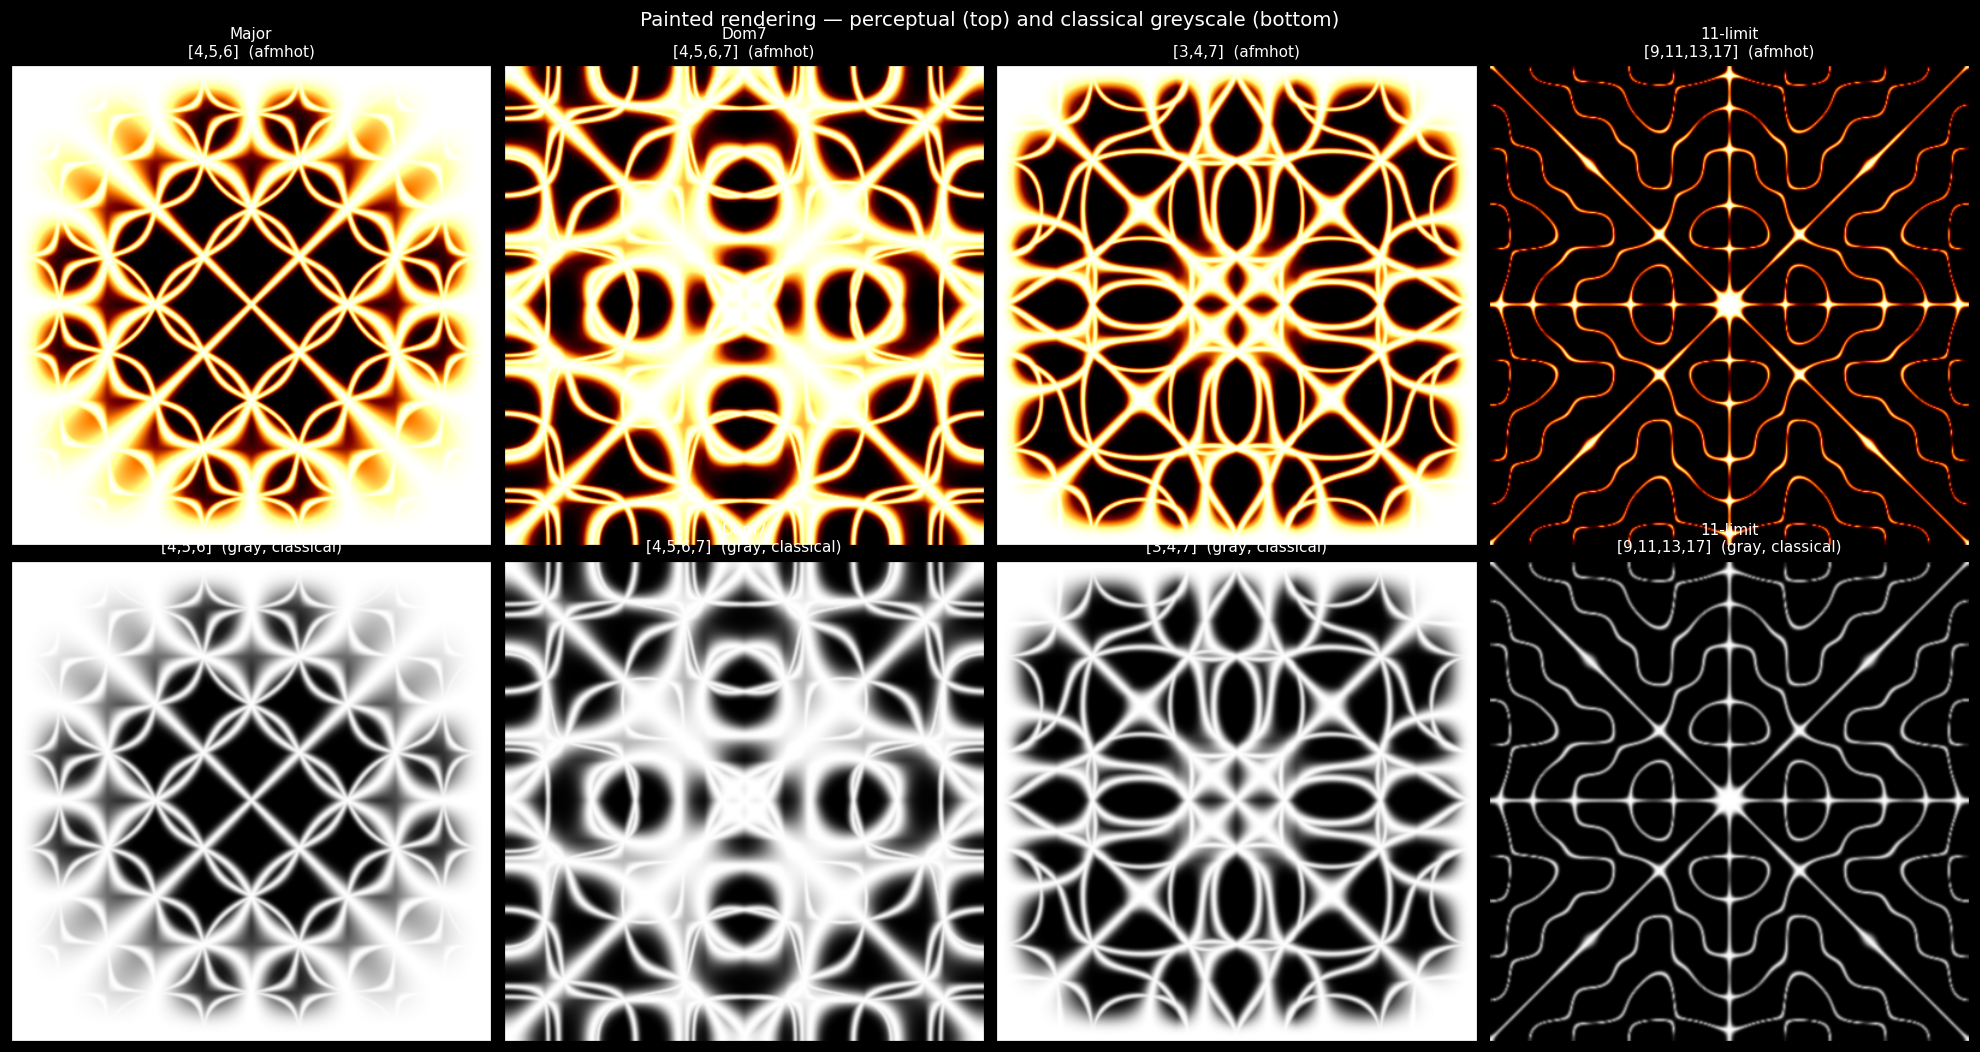

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9.5), facecolor="black")
chords_gamut = [
    ("Major\n[4,5,6]",    [4, 5, 6]),
    ("Dom7\n[4,5,6,7]",   [4, 5, 6, 7]),
    ("[3,4,7]",            [3, 4, 7]),
    ("11-limit\n[9,11,13,17]", [9, 11, 13, 17]),
]
for ax, (name, chord) in zip(axes[0], chords_gamut):
    f = chladni_field_pairwise(
        chord, antisymmetric=True, symmetry="d4_max", resolution=400,
    )
    plotting.draw_chladni_painted(f, ax, cmap="afmhot", gamma=0.85)
    ax.set_title(f"{name}  (afmhot)", color="white", fontsize=10)
for ax, (name, chord) in zip(axes[1], chords_gamut):
    f = chladni_field_pairwise(
        chord, antisymmetric=True, symmetry="d4_max", resolution=400,
    )
    plotting.draw_chladni_painted(f, ax, cmap="gray", gamma=0.55)
    ax.set_title(f"{name}  (gray, classical)", color="white", fontsize=10)
fig.suptitle("Painted rendering — perceptual (top) and classical greyscale (bottom)",
             color="white", fontsize=13, y=0.995)
fig.tight_layout(pad=0.6);


## 7. `max_mode` — taming high-LCM chords

Chords whose ``Fraction`` form has a large LCM (e.g. 12-TET-flavoured
Dim7 = ``[35, 42, 49, 60]``) produce sub-pixel-fine lattices that
read as dots rather than curves. ``max_mode`` scales all wavenumbers
proportionally down to a visible range — ratios are preserved.


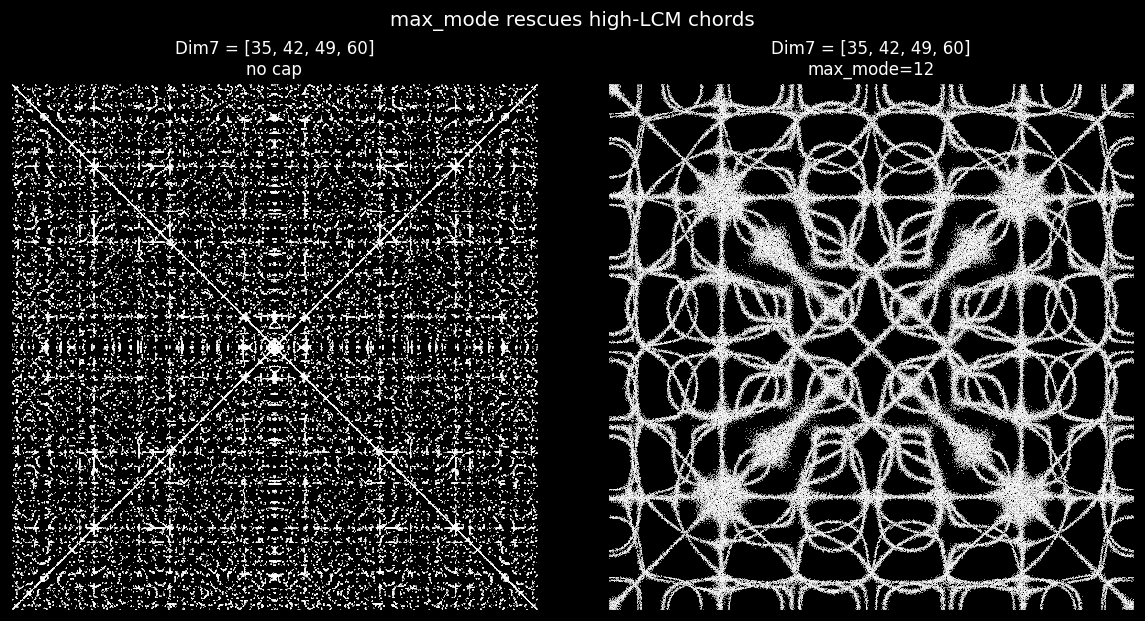

In [8]:
dim7_blown = [35, 42, 49, 60]
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6), facecolor="black")
for ax, cap in zip(axes, [None, 12]):
    f = chladni_field_pairwise(
        dim7_blown, antisymmetric=True, symmetry="d4_max",
        resolution=480, max_mode=cap,
    )
    plotting.draw_chladni_sand(f, ax, n_particles=300_000,
                                point_size=0.4, point_alpha=0.4)
    title = "no cap" if cap is None else f"max_mode={cap}"
    ax.set_title(f"Dim7 = {dim7_blown}\n{title}",
                  color="white", fontsize=11)
fig.suptitle("max_mode rescues high-LCM chords",
             color="white", fontsize=13, y=1.0)
fig.tight_layout();


## 8. Pipeline composition: `RigidPlate → Granular`

The `Granular` transport medium picks up a wave field and samples a
density-weighted point cloud. With ``nodal_emphasis=True`` it uses
``exp(-w²/σ²)`` directly on the input field (auto-σ from metadata)
and applies any D4 symmetrisation from the upstream
``RigidPlate.symmetry`` setting. So the entire cymatics flow becomes
a clean Pipeline:


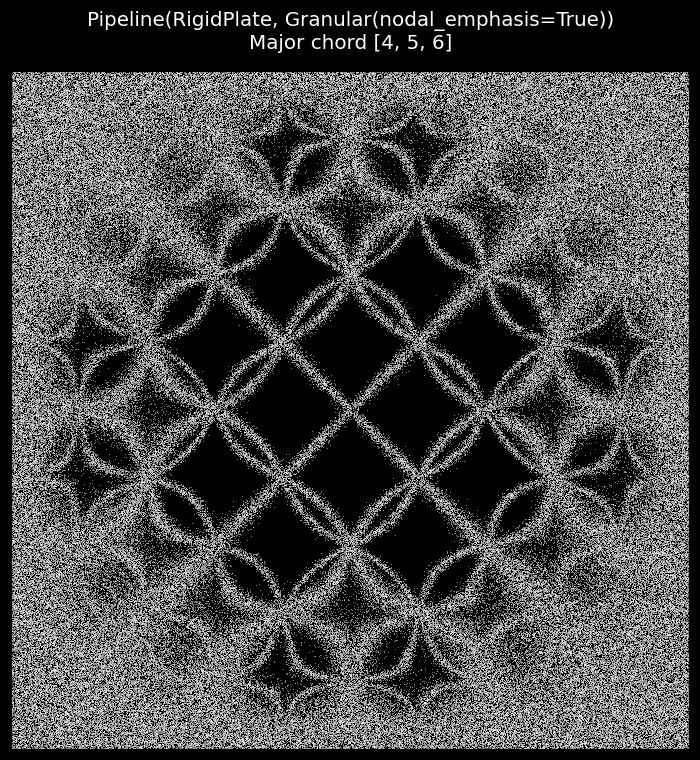

In [9]:
pipeline = Pipeline(
    RigidPlate(mode_scheme="pairwise_antisymmetric",
               symmetry="d4_max", resolution=400),
    Granular(output_mode="particles", nodal_emphasis=True,
             n_particles=400_000, seed=0),
)
chord = HarmonicInput(ratios=[Fraction(4), Fraction(5), Fraction(6)])
result = pipeline(chord)

fig, ax = plt.subplots(figsize=(7, 7), facecolor="black")
ax.set_facecolor("black")
pts = result.coordinates
ax.scatter(pts[:, 0], pts[:, 1], s=0.4, c="white", alpha=0.4, linewidths=0)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.suptitle("Pipeline(RigidPlate, Granular(nodal_emphasis=True))\nMajor chord [4, 5, 6]",
             color="white", fontsize=13)
fig.tight_layout();


## 9. Animation — chord-sequence morph

`plotting.animate_chord_sequence` drives a user-supplied
chord→geometry builder through a cosine-eased loop of chord
keyframes. Cell builds the FuncAnimation object — pass
``save_path='out.mp4'`` to write a CRF-18 H.264 MP4 (requires ffmpeg).


In [10]:
# Short illustrative animation (not saved to disk in the notebook).
chord_keyframes = [[2, 3, 5], [2, 5, 7], [3, 4, 7]]
def builder(chord):
    return Pipeline(
        RigidPlate(mode_scheme="pairwise_antisymmetric",
                   symmetry="d4_max", resolution=300),
        Granular(output_mode="particles", nodal_emphasis=True,
                 n_particles=80_000, seed=0),
    )(HarmonicInput(ratios=[Fraction(r) for r in chord]))

anim = plotting.animate_chord_sequence(
    chord_keyframes, builder,
    frames_per_segment=12, fps=24, loop=True,
    figsize=(5, 5),
    point_size=0.4, point_alpha=0.4,
)
print(f"FuncAnimation built — {len(chord_keyframes) * 12} frames @ 24 fps")
print("To save MP4: pass save_path='out.mp4' to animate_chord_sequence().")
plt.close("all");


## Recipe quick reference

| Goal | One-liner |
|---|---|
| classical Chladni (default) | `RigidPlate()(chord)` |
| cymatics nodal lattice | `RigidPlate(mode_scheme='pairwise_antisymmetric', symmetry='d4_max')(chord)` |
| sand-on-the-nodes density | add `output='nodal_density'` (or wrap via `chladni_nodal_density`) |
| photographic sand grains | `Pipeline(plate, Granular(output_mode='particles', nodal_emphasis=True))(chord)` |
| perceptual painted view | `plotting.draw_chladni_painted(field, ax, cmap='afmhot')` |
| classical greyscale | `plotting.draw_chladni_painted(field, ax, cmap='gray', gamma=0.55)` |
| triadic mode flavour | `mode_scheme='triple_antisymmetric'` (needs ≥3 ratios) |
| smooth D4 averaging | `symmetry='d4_sum'` (orbit-average instead of orbit-max) |
| cap high-LCM chords | `max_mode=12` (or any cap) — proportional scale-down |
| chord-morph MP4 | `plotting.animate_chord_sequence(keyframes, builder, save_path='out.mp4')` |
